In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("../data/creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
df.duplicated().sum()

np.int64(1081)

In [10]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [11]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

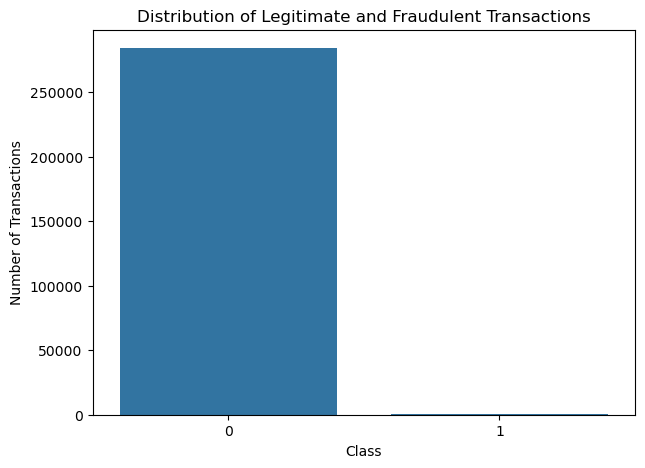

In [12]:
plt.figure(figsize=(7,5))

sns.countplot(x="Class", data=df)

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

In [13]:
df.isnull().sum().sum()

np.int64(0)

In [14]:
df.duplicated().sum()

np.int64(1081)

In [15]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [16]:
df[df.duplicated()]["Class"].value_counts()

Class
0    1062
1      19
Name: count, dtype: int64

In [17]:
df[df.duplicated()].head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0


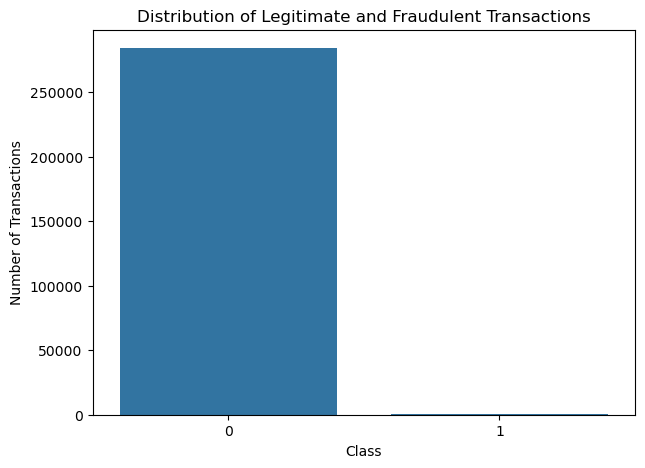

In [18]:
plt.figure(figsize=(7,5))

sns.countplot(x="Class", data=df)

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

In [20]:
df_clean = df.drop_duplicates()

In [21]:
df_clean.shape

(283726, 31)

In [22]:
df_clean.duplicated().sum()

np.int64(0)

In [23]:
df_clean["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [24]:
df_clean["Class"].value_counts(normalize=True) * 100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

In [25]:
df_clean = df.drop_duplicates()
df_clean.shape
df_clean.duplicated().sum()
df_clean["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

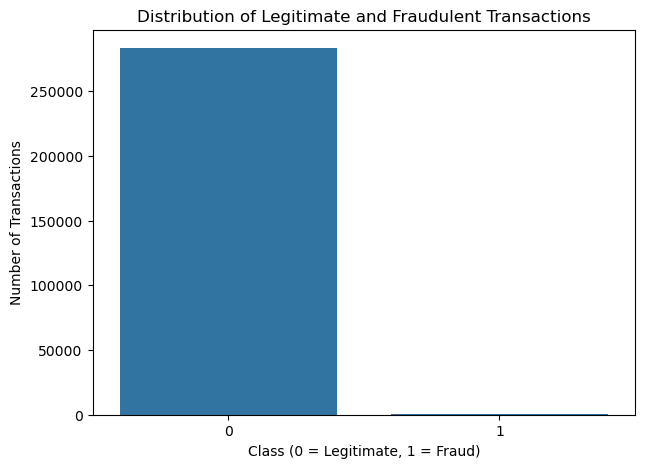

In [26]:
plt.figure(figsize=(7, 5))

sns.countplot(x="Class", data=df_clean)

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

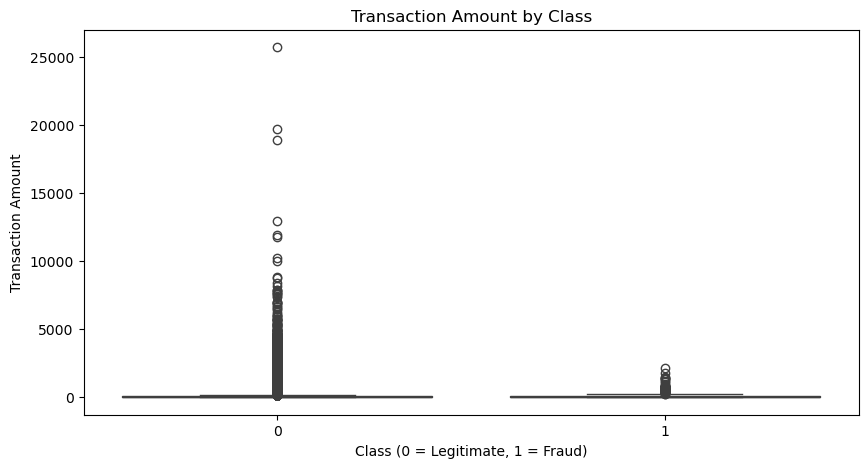

In [27]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df_clean
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

In [28]:
df_clean.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


In [29]:
df_clean["Class"].value_counts(normalize=True) * 100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

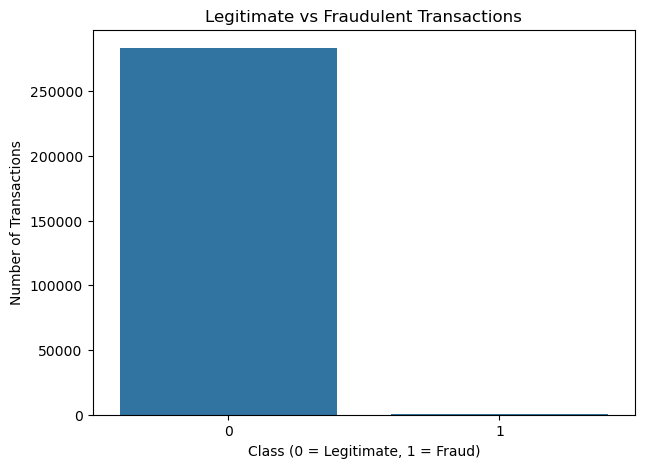

In [30]:
plt.figure(figsize=(7, 5))

sns.countplot(x="Class", data=df_clean)

plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

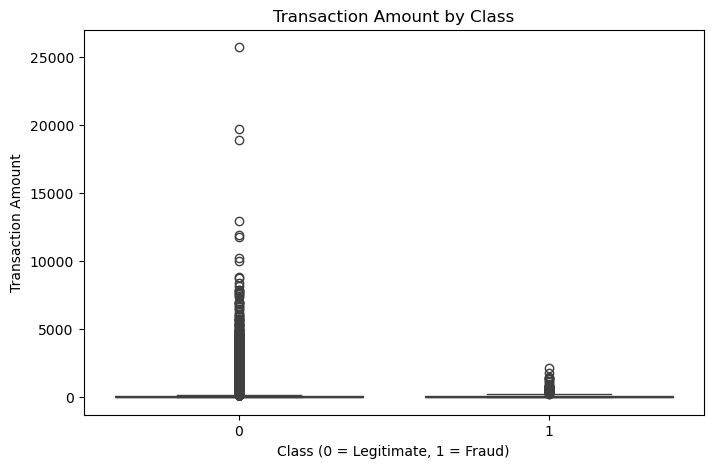

In [31]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df_clean
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

In [33]:
df_clean = df.drop_duplicates().copy()

In [34]:
df_clean["LogAmount"] = np.log1p(df_clean["Amount"])

In [35]:
df_clean[["Amount", "LogAmount"]].head()

,Amount,LogAmount
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


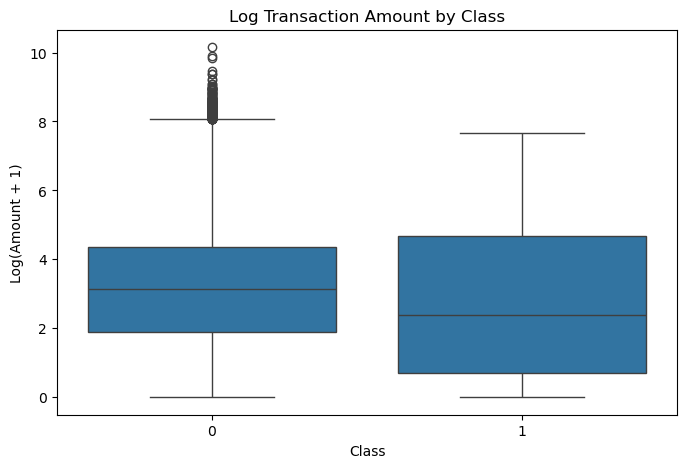

In [36]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Class",
    y="LogAmount",
    data=df_clean
)

plt.title("Log Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Log(Amount + 1)")

plt.show()

In [37]:
df_clean["Hour"] = (df_clean["Time"] / 3600) % 24

In [38]:
df_clean[["Time", "Hour"]].head()

,Time,Hour
0,0.0,0.000000
1,0.0,0.000000
2,1.0,0.000278
3,1.0,0.000278
4,2.0,0.000556


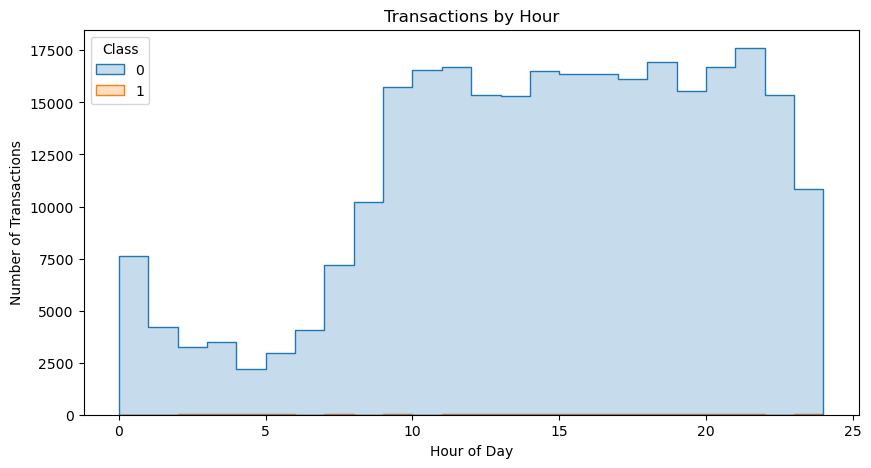

In [39]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_clean,
    x="Hour",
    hue="Class",
    bins=24,
    element="step"
)

plt.title("Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.show()

In [40]:
df_clean.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
Class,,,,,,
0,283253,88.413575,22.00,250.379023,0.0,25691.16
1,473,123.871860,9.82,260.211041,0.0,2125.87


In [41]:
correlations = df_clean.corr()["Class"].sort_values()

correlations

V17         -0.313498
V14         -0.293375
V12         -0.250711
V10         -0.206971
V16         -0.187186
V3          -0.182322
V7          -0.172347
V18         -0.105340
V1          -0.094486
V9          -0.094021
V5          -0.087812
V6          -0.043915
Hour        -0.016696
Time        -0.012359
LogAmount   -0.007798
V24         -0.007210
V23         -0.006333
V13         -0.003897
V15         -0.003300
V25          0.003202
V26          0.004265
V22          0.004887
Amount       0.005777
V28          0.009682
V20          0.021486
V27          0.021892
V21          0.026357
V8           0.033068
V19          0.033631
V2           0.084624
V4           0.129326
V11          0.149067
Class        1.000000
Name: Class, dtype: float64

In [42]:
top_features = correlations.abs().sort_values(
    ascending=False
).head(10)

top_features

Class    1.000000
V17      0.313498
V14      0.293375
V12      0.250711
V10      0.206971
V16      0.187186
V3       0.182322
V7       0.172347
V11      0.149067
V4       0.129326
Name: Class, dtype: float64

In [43]:
df_clean[["Time", "Hour", "Amount", "LogAmount"]].head()

,Time,Hour,Amount,LogAmount
0,0.0,0.000000,149.62,5.014760
1,0.0,0.000000,2.69,1.305626
2,1.0,0.000278,378.66,5.939276
3,1.0,0.000278,123.50,4.824306
4,2.0,0.000556,69.99,4.262539


In [45]:
X.shape
y.shape

(283726,)

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
X = df_clean.drop("Class", axis=1)
y = df_clean["Class"]

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [50]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTraining classes:")
print(y_train.value_counts())

print("\nTesting classes:")
print(y_test.value_counts())

X_train: (226980, 32)
X_test: (56746, 32)

Training classes:
Class
0    226602
1       378
Name: count, dtype: int64

Testing classes:
Class
0    56651
1       95
Name: count, dtype: int64


In [51]:
from sklearn.preprocessing import StandardScaler

In [52]:
scaler = StandardScaler()

In [53]:
X_train_scaled = scaler.fit_transform(X_train)

In [54]:
X_test_scaled = scaler.transform(X_test)

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(226980, 32)
(56746, 32)


In [57]:
!pip install imbalanced-learn

In [58]:
from imblearn.over_sampling import SMOTE

In [59]:
smote = SMOTE(
    random_state=42
)

In [60]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [61]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


In [62]:
from sklearn.linear_model import LogisticRegression

In [63]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [64]:
logistic_model.fit(
    X_train_smote,
    y_train_smote
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [65]:
y_pred = logistic_model.predict(X_test_scaled)

In [66]:
y_pred_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [67]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [68]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.9731963486413139
Precision: 0.052135678391959796
Recall   : 0.8736842105263158
F1 Score : 0.0983995257854179
ROC-AUC  : 0.9653299193863815


In [69]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[55142  1509]
 [   12    83]]


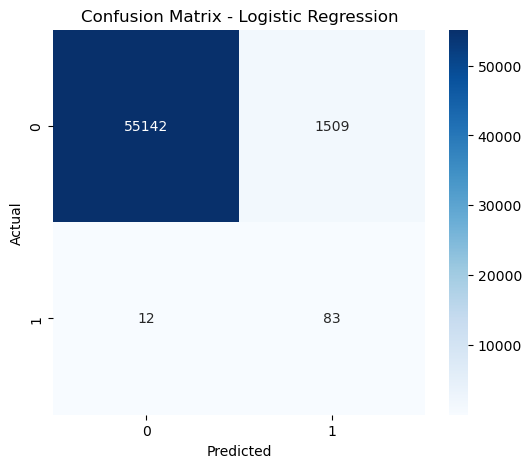

In [70]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [71]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746



In [72]:
from sklearn.ensemble import RandomForestClassifier

In [73]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight=None
)

In [74]:
rf_model.fit(
    X_train_smote,
    y_train_smote
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [75]:
rf_pred = rf_model.predict(X_test_scaled)

In [76]:
rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

In [77]:
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_pred_proba)

print("Random Forest Results")
print("---------------------")
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_roc_auc)

Random Forest Results
---------------------
Precision: 0.9230769230769231
Recall   : 0.7578947368421053
F1 Score : 0.8323699421965318
ROC-AUC  : 0.9585240749222617


In [78]:
print(confusion_matrix(y_test, rf_pred))

[[56645     6]
 [   23    72]]


In [80]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 2.1 MB/s  0:00:01 eta 0:00:01


In [81]:
from xgboost import XGBClassifier

In [82]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

In [83]:
xgb_model.fit(
    X_train_smote,
    y_train_smote
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [84]:
xgb_pred = xgb_model.predict(X_test_scaled)

In [85]:
xgb_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

In [86]:
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_pred_proba)

print("XGBoost Results")
print("----------------")
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC-AUC  :", xgb_roc_auc)

XGBoost Results
----------------
Precision: 0.7281553398058253
Recall   : 0.7894736842105263
F1 Score : 0.7575757575757576
ROC-AUC  : 0.9739095050117571


In [87]:
print(confusion_matrix(y_test, xgb_pred))

[[56623    28]
 [   20    75]]


In [88]:
import joblib

joblib.dump(rf_model, "fraud_detection_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [89]:
import os

print(os.listdir())

['scaler.pkl', 'fraud_detection.ipynb', '.ipynb_checkpoints', 'fraud_detection_model.pkl']


In [90]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
14,V14,0.181122
12,V12,0.125378
10,V10,0.118088
17,V17,0.104641
4,V4,0.088741
11,V11,0.060714
16,V16,0.046944
7,V7,0.036967
3,V3,0.035684
2,V2,0.021484


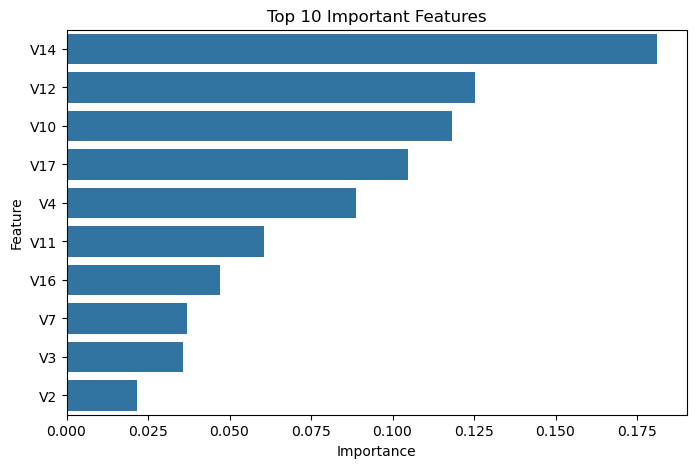

In [91]:
top10 = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

In [92]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(rf_model, "../models/fraud_detection_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [93]:
print(os.path.exists("../models/fraud_detection_model.pkl"))
print(os.path.exists("../models/scaler.pkl"))

True
True


In [95]:
import os

os.listdir()

['scaler.pkl',
 'fraud_detection.ipynb',
 '.ipynb_checkpoints',
 'fraud_detection_model.pkl']